# Processing Time Analysis of Different Distance Metrics in Time Series Forecasting

This notebook aims at analyzing the processing time of various distance metrics used in time series forecasting with the `cbr_fox` library. We will load precomputed datasets, apply different distance metrics, and measure the execution time for each metric across various datasets and window lengths. Finally, we will visualize the results using line plots to compare the performance of each metric.

## 1. Import Necessary Libraries

In [1]:
import sys
import os
import numpy as np
import cProfile
import re
import pstats
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from cbr_fox.core import cbr_fox
from cbr_fox.builder import cbr_fox_builder
from cbr_fox.custom_distance import cci_distance


## 2. Define Constants and Variables

In [7]:
# Constants and variables for handling loop operation
dataset_names = ["weather"
    , "power", "BTC"
    ,"Rainfall", "Romania", "Walmart", "creditcard"
                 ]
window_len_suffix = ["_L7", "_L14"]
# dictionary to hold cumulative values for each dataset and its respectives window len file
cumulative_values = dict()
FILE_EXTENSION = ".npz"

techniques = [
    cbr_fox(metric=cci_distance, kwargs={"punishedSumFactor": 0.6}),
    cbr_fox(metric="edr"),
    cbr_fox(metric="dtw"),
    cbr_fox(metric="euclidean"),
    # cbr_fox(metric="wdtw"),
    # cbr_fox(metric="ddtw"),
    # cbr_fox(metric="erp"),
    # cbr_fox(metric="msm")
]
diccionario = {}

## 2.1 Single execution example to measure execution time for a specific metric, dataset and window length

In [5]:
data = np.load("weather" + "_L14" + FILE_EXTENSION)
# Retrieve each variable
training_windows = data['training_windows']
forecasted_window = data['forecasted_window']
target_training_windows = data['target_training_windows']
windowsLen = data['windowsLen'].item()  # Extract single value from array
componentsLen = data['componentsLen'].item()
windowLen = data['windowLen'].item()
prediction = data['prediction']

p = cbr_fox_builder([techniques[1]])
pr = cProfile.Profile()
pr.enable()
# --- your code here ---
p.fit(training_windows=training_windows,
      target_training_windows=target_training_windows,
      forecasted_window=forecasted_window)
# ----------------------
pr.disable()
# Dump stats into a string
stats = pstats.Stats(pr)

total_cumulative_time = sum([stat[2] for stat in stats.stats.values()])
print(f"Total cumulative time: {total_cumulative_time:.6f} seconds")

Exception ignored When destroying _lsprof profiler:
Traceback (most recent call last):
  File "C:\Users\jerry\AppData\Local\Temp\ipykernel_19020\3365604312.py", line 13, in <module>
RuntimeError: Cannot install a profile function while another profile function is being installed
2025-10-15 16:19:20,058 - INFO - Analizando conjunto de datos
2025-10-15 16:19:20,059 - INFO - Calculando Correlación


DEBUG: cbr_fox_builder.__init__ called
DEBUG: techniques parameter type: <class 'list'>
DEBUG: techniques parameter value: [<cbr_fox.core.cbr_fox.cbr_fox object at 0x000001FF9BA45510>]
DEBUG: techniques length: 1
DEBUG: Starting loop through techniques...
DEBUG: Processing item 0: <cbr_fox.core.cbr_fox.cbr_fox object at 0x000001FF9BA45510>
DEBUG: Item type: <class 'cbr_fox.core.cbr_fox.cbr_fox'>
DEBUG: Item has 'metric' attribute
DEBUG: item.metric = edr
DEBUG: item.metric type = <class 'str'>
DEBUG: Metric is string: 'edr'
DEBUG: Adding to dict with key: 'edr'
DEBUG: Successfully added string metric to dict
DEBUG: Final techniques_dict keys: ['edr']
DEBUG: cbr_fox_builder.__init__ completed successfully


Windows procesadas: 100%|██████████| 6834/6834 [00:12<00:00, 547.94it/s]
2025-10-15 16:19:32,535 - INFO - Computando análisis de CBR
2025-10-15 16:19:32,536 - INFO - Suavizando Correlación
2025-10-15 16:19:33,500 - INFO - Extrayendo crestas y valles
2025-10-15 16:19:33,501 - INFO - Recuperando segmentos convexos y cóncavos
2025-10-15 16:19:33,502 - INFO - Recuperando índices originales de correlación
Segmentos convexos: 100%|██████████| 8/8 [00:00<?, ?it/s]
2025-10-15 16:19:33,508 - INFO - Análisis finalizado


Total cumulative time: 13.450477 seconds


# 3. Iterative flow control construct to measure execution time for each metric, dataset and window length

In [8]:
for dataset in dataset_names:
    diccionario[dataset] = {}
    for technique in techniques:
        metrica = ""
        if callable(technique.metric):
            metrica = technique.metric.__name__
        else:
            metrica = technique.metric
        diccionario[dataset][metrica] = dict()

        for window_len in window_len_suffix:
            data = np.load(dataset + window_len + FILE_EXTENSION)
            # Retrieve each variable
            training_windows = data['training_windows']
            forecasted_window = data['forecasted_window']
            target_training_windows = data['target_training_windows']
            windowsLen = data['windowsLen'].item()  # Extract single value from array
            componentsLen = data['componentsLen'].item()
            windowLen = data['windowLen'].item()
            prediction = data['prediction']  
            
            p = cbr_fox_builder([technique])
            pr = cProfile.Profile()
            pr.enable()
            # --- your code here ---
            p.fit(training_windows=training_windows,
                  target_training_windows=target_training_windows,
                  forecasted_window=forecasted_window)
            # ----------------------
            pr.disable()
            # Dump stats into a string
            stats = pstats.Stats(pr)

            total_cumulative_time = sum([stat[2] for stat in stats.stats.values()])
            print(f"Total cumulative time: {total_cumulative_time:.6f} seconds")
            print("saving: " + dataset + " " + str(metrica) + " " + window_len)
            diccionario[dataset][metrica][window_len] = total_cumulative_time

Exception ignored When destroying _lsprof profiler:
Traceback (most recent call last):
  File "C:\Users\jerry\AppData\Local\Temp\ipykernel_19020\2811546755.py", line 24, in <module>
RuntimeError: Cannot install a profile function while another profile function is being installed
2025-10-15 17:18:03,506 - INFO - Analizando conjunto de datos
2025-10-15 17:18:03,506 - INFO - Calculando Correlación


DEBUG: cbr_fox_builder.__init__ called
DEBUG: techniques parameter type: <class 'list'>
DEBUG: techniques parameter value: [<cbr_fox.core.cbr_fox.cbr_fox object at 0x000001FF9E9E1B40>]
DEBUG: techniques length: 1
DEBUG: Starting loop through techniques...
DEBUG: Processing item 0: <cbr_fox.core.cbr_fox.cbr_fox object at 0x000001FF9E9E1B40>
DEBUG: Item type: <class 'cbr_fox.core.cbr_fox.cbr_fox'>
DEBUG: Item has 'metric' attribute
DEBUG: item.metric = <function cci_distance at 0x000001FFF6031FC0>
DEBUG: item.metric type = <class 'function'>
DEBUG: Metric is not string, checking for __name__ attribute...
DEBUG: item.metric.__name__ = cci_distance
DEBUG: Adding to dict with key: 'cci_distance'
DEBUG: Successfully added callable metric to dict
DEBUG: Final techniques_dict keys: ['cci_distance']
DEBUG: cbr_fox_builder.__init__ completed successfully


Windows procesadas:   0%|          | 0/6841 [00:00<?, ?it/s]2025-10-15 17:18:03,509 - INFO - Aplicando Correlación de Pearson
2025-10-15 17:18:03,509 - WARNING - Failed with sktime metric: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Windows procesadas:   0%|          | 0/6841 [00:00<?, ?it/s]
2025-10-15 17:18:03,510 - INFO - Aplicando Correlación de Pearson
Windows procesadas: 100%|██████████| 6841/6841 [00:02<00:00, 2851.78it/s]
2025-10-15 17:18:05,914 - INFO - Aplicando Correlación Euclidiana
Windows procesadas: 100%|██████████| 6841/6841 [00:00<00:00, 22626.41it/s]
2025-10-15 17:18:06,228 - INFO - Computando análisis de CBR
2025-10-15 17:18:06,229 - INFO - Suavizando Correlación
2025-10-15 17:18:07,309 - INFO - Extrayendo crestas y valles
2025-10-15 17:18:07,310 - INFO - Recuperando segmentos convexos y cóncavos
2025-10-15 17:18:07,311 - INFO - Recuperando índices originales de correlación
Segmentos convexos: 

Total cumulative time: 3.811476 seconds
saving: weather cci_distance _L7
DEBUG: cbr_fox_builder.__init__ called
DEBUG: techniques parameter type: <class 'list'>
DEBUG: techniques parameter value: [<cbr_fox.core.cbr_fox.cbr_fox object at 0x000001FF9E9E1B40>]
DEBUG: techniques length: 1
DEBUG: Starting loop through techniques...
DEBUG: Processing item 0: <cbr_fox.core.cbr_fox.cbr_fox object at 0x000001FF9E9E1B40>
DEBUG: Item type: <class 'cbr_fox.core.cbr_fox.cbr_fox'>
DEBUG: Item has 'metric' attribute
DEBUG: item.metric = <function cci_distance at 0x000001FFF6031FC0>
DEBUG: item.metric type = <class 'function'>
DEBUG: Metric is not string, checking for __name__ attribute...
DEBUG: item.metric.__name__ = cci_distance
DEBUG: Adding to dict with key: 'cci_distance'
DEBUG: Successfully added callable metric to dict
DEBUG: Final techniques_dict keys: ['cci_distance']
DEBUG: cbr_fox_builder.__init__ completed successfully


Windows procesadas:   0%|          | 0/6834 [00:00<?, ?it/s]2025-10-15 17:18:07,325 - INFO - Aplicando Correlación de Pearson
2025-10-15 17:18:07,325 - WARNING - Failed with sktime metric: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Windows procesadas:   0%|          | 0/6834 [00:00<?, ?it/s]
2025-10-15 17:18:07,326 - INFO - Aplicando Correlación de Pearson
Windows procesadas: 100%|██████████| 6834/6834 [00:02<00:00, 2942.92it/s]
2025-10-15 17:18:09,650 - INFO - Aplicando Correlación Euclidiana
Windows procesadas: 100%|██████████| 6834/6834 [00:00<00:00, 18284.88it/s]
2025-10-15 17:18:10,037 - INFO - Computando análisis de CBR
2025-10-15 17:18:10,037 - INFO - Suavizando Correlación
2025-10-15 17:18:10,974 - INFO - Extrayendo crestas y valles
2025-10-15 17:18:10,975 - INFO - Recuperando segmentos convexos y cóncavos
2025-10-15 17:18:10,976 - INFO - Recuperando índices originales de correlación
Segmentos convexos: 

...

Total cumulative time: 302.157856 seconds
saving: creditcard dtw _L14
DEBUG: cbr_fox_builder.__init__ called
DEBUG: techniques parameter type: <class 'list'>
DEBUG: techniques parameter value: [<cbr_fox.core.cbr_fox.cbr_fox object at 0x000001FF9E9E3EE0>]
DEBUG: techniques length: 1
DEBUG: Starting loop through techniques...
DEBUG: Processing item 0: <cbr_fox.core.cbr_fox.cbr_fox object at 0x000001FF9E9E3EE0>
DEBUG: Item type: <class 'cbr_fox.core.cbr_fox.cbr_fox'>
DEBUG: Item has 'metric' attribute
DEBUG: item.metric = euclidean
DEBUG: item.metric type = <class 'str'>
DEBUG: Metric is string: 'euclidean'
DEBUG: Adding to dict with key: 'euclidean'
DEBUG: Successfully added string metric to dict
DEBUG: Final techniques_dict keys: ['euclidean']
DEBUG: cbr_fox_builder.__init__ completed successfully


Windows procesadas: 100%|██████████| 24766/24766 [00:05<00:00, 4818.89it/s]
2025-10-15 18:35:59,871 - INFO - Computando análisis de CBR
2025-10-15 18:35:59,871 - INFO - Suavizando Correlación
2025-10-15 18:36:09,510 - INFO - Extrayendo crestas y valles
2025-10-15 18:36:09,512 - INFO - Recuperando segmentos convexos y cóncavos
2025-10-15 18:36:09,512 - INFO - Recuperando índices originales de correlación
Segmentos convexos: 100%|██████████| 1/1 [00:00<00:00, 930.41it/s]
2025-10-15 18:36:09,519 - INFO - Análisis finalizado
2025-10-15 18:36:09,579 - INFO - Analizando conjunto de datos
2025-10-15 18:36:09,581 - INFO - Calculando Correlación


Total cumulative time: 14.805929 seconds
saving: creditcard euclidean _L7
DEBUG: cbr_fox_builder.__init__ called
DEBUG: techniques parameter type: <class 'list'>
DEBUG: techniques parameter value: [<cbr_fox.core.cbr_fox.cbr_fox object at 0x000001FF9E9E3EE0>]
DEBUG: techniques length: 1
DEBUG: Starting loop through techniques...
DEBUG: Processing item 0: <cbr_fox.core.cbr_fox.cbr_fox object at 0x000001FF9E9E3EE0>
DEBUG: Item type: <class 'cbr_fox.core.cbr_fox.cbr_fox'>
DEBUG: Item has 'metric' attribute
DEBUG: item.metric = euclidean
DEBUG: item.metric type = <class 'str'>
DEBUG: Metric is string: 'euclidean'
DEBUG: Adding to dict with key: 'euclidean'
DEBUG: Successfully added string metric to dict
DEBUG: Final techniques_dict keys: ['euclidean']
DEBUG: cbr_fox_builder.__init__ completed successfully


Windows procesadas: 100%|██████████| 47454/47454 [00:11<00:00, 4118.34it/s]
2025-10-15 18:36:21,137 - INFO - Computando análisis de CBR
2025-10-15 18:36:21,138 - INFO - Suavizando Correlación
2025-10-15 18:36:54,686 - INFO - Extrayendo crestas y valles
2025-10-15 18:36:54,688 - INFO - Recuperando segmentos convexos y cóncavos
2025-10-15 18:36:54,689 - INFO - Recuperando índices originales de correlación
Segmentos convexos: 100%|██████████| 1/1 [00:00<00:00, 459.15it/s]
2025-10-15 18:36:54,696 - INFO - Análisis finalizado


Total cumulative time: 45.117607 seconds
saving: creditcard euclidean _L14


## 4. Visualization of Results. A comprehensive dictionary containing execution times for each metric, dataset, and window length

In [10]:
diccionario

{'weather': {'cci_distance': {'_L7': 3.8114762000000004,
   '_L14': 3.659134499999999},
  'edr': {'_L7': 5.1617644999999985, '_L14': 13.502070900000005},
  'dtw': {'_L7': 3.368288099999999, '_L14': 9.1881723},
  'euclidean': {'_L7': 1.2219921000000016, '_L14': 1.2683601999999996}},
 'power': {'cci_distance': {'_L7': 547.4781384999997,
   '_L14': 266.6034554999998},
  'edr': {'_L7': 186.77752319999982, '_L14': 524.1324754000001},
  'dtw': {'_L7': 161.11018310000003, '_L14': 330.3815393999999},
  'euclidean': {'_L7': 228.1879234, '_L14': 227.4868718999998}},
 'BTC': {'cci_distance': {'_L7': 2.2538127999999977,
   '_L14': 2.3618690999999994},
  'edr': {'_L7': 3.607215499999997, '_L14': 19.354865099999998},
  'dtw': {'_L7': 2.066684199999999, '_L14': 6.392017999999999},
  'euclidean': {'_L7': 0.4563566000000002, '_L14': 0.5077632000000003}},
 'Rainfall': {'cci_distance': {'_L7': 0.21331720000000004, '_L14': 0.2054624},
  'edr': {'_L7': 0.3164266999999998, '_L14': 0.8262025999999995},
  'dt

## 5.1 Define colors and metric name mapping for plotting

In [12]:
plt.style.use("seaborn-v0_8-whitegrid")

colors = [
    "#0072B2",  # Blue
    "#E69F00",  # Orange
    "#009E73",  # Green
    "#D55E00",  # Red
    "#CC79A7",  # Pink
    "#56B4E9",  # Light Blue
    "#F0E442",  # Yellow
    "#999999",  # Gray
    "#8B4513",  # Brown
    "#800080",  # Purple
    "#00CED1",  # Teal
    "#FFD700"   # Gold
]

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

metric_name_map = {
    "edr": "Edit Distance on Real sequence",
    "dtw": "Dynamic Time Warping",
    "cci_distance": "CCI Distance",
    "euclidean": "Euclidean Distance",
    "wdtw": "Weighted Dynamic Time Warping",
    "ddtw": "Derivative Dynamic Time Warping",
    "erp": "Edit Distance with Real Penalty",
    "msm": "Move-Split-Merge Distance"
}

## 5.2 Plotting the results

2025-10-15 18:39:00,930 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:00,932 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:00,934 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:00,935 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:00,935 - INFO - Using categorical units to plot a list of strings that are all parsable as 

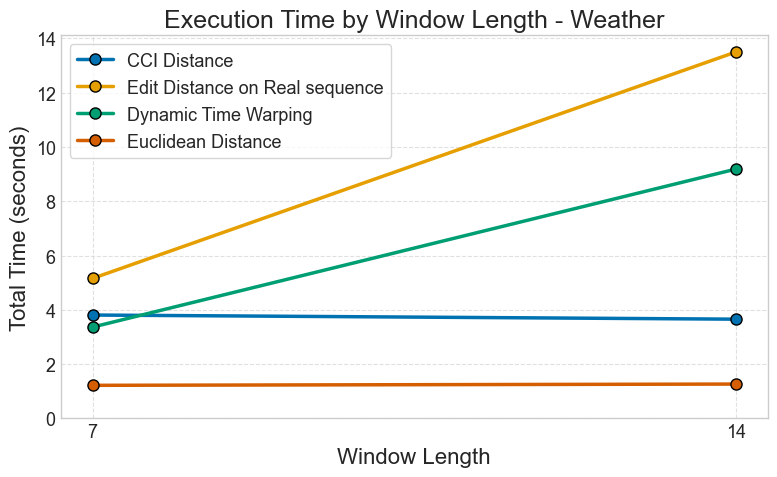

2025-10-15 18:39:01,064 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,073 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,074 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,074 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,075 - INFO - Using categorical units to plot a list of strings that are all parsable as 

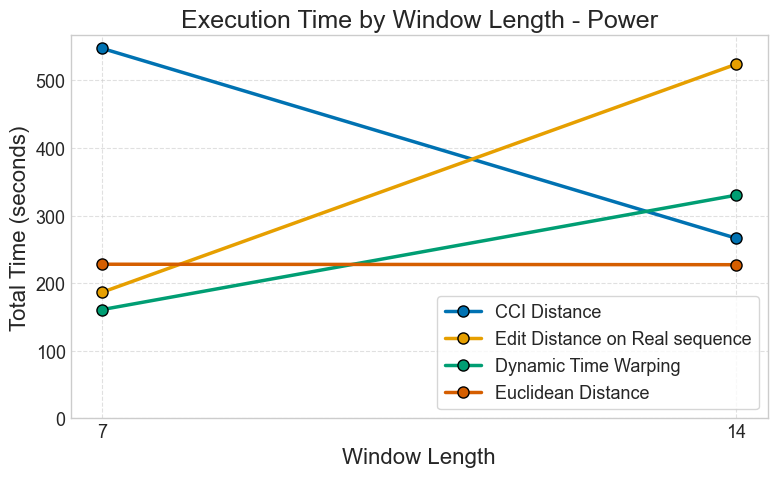

2025-10-15 18:39:01,169 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,170 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,171 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,172 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,172 - INFO - Using categorical units to plot a list of strings that are all parsable as 

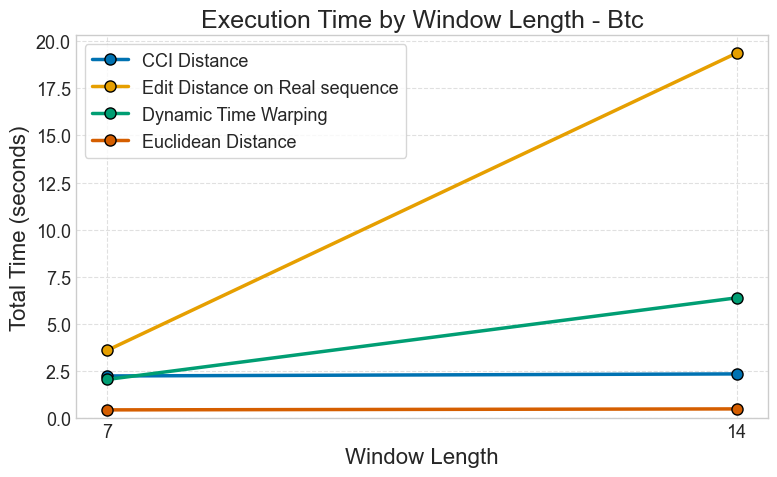

2025-10-15 18:39:01,279 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,280 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,280 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,281 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,281 - INFO - Using categorical units to plot a list of strings that are all parsable as 

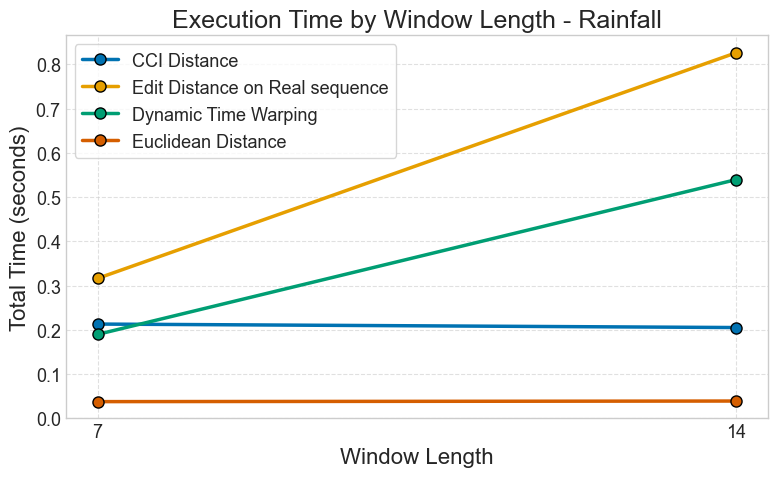

2025-10-15 18:39:01,389 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,390 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,391 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,392 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,392 - INFO - Using categorical units to plot a list of strings that are all parsable as 

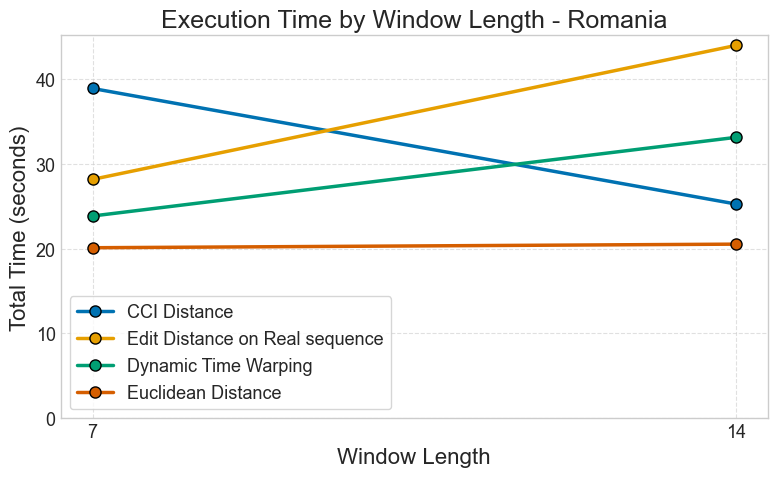

2025-10-15 18:39:01,484 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,485 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,486 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,487 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,488 - INFO - Using categorical units to plot a list of strings that are all parsable as 

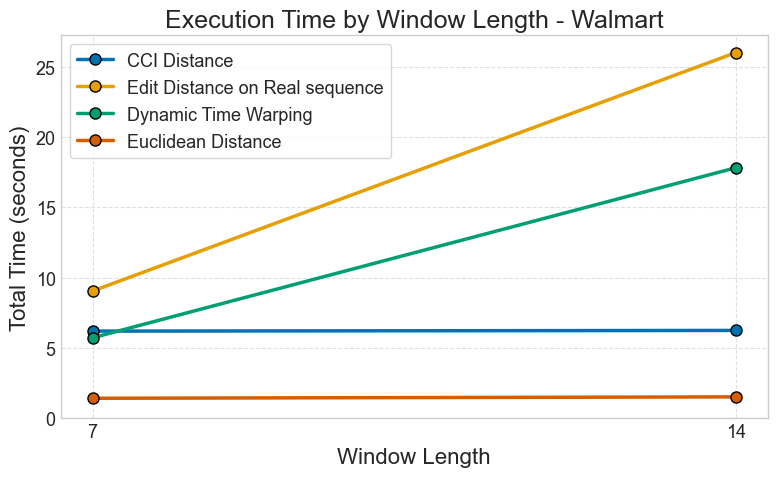

2025-10-15 18:39:01,578 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,579 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,579 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,580 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:39:01,580 - INFO - Using categorical units to plot a list of strings that are all parsable as 

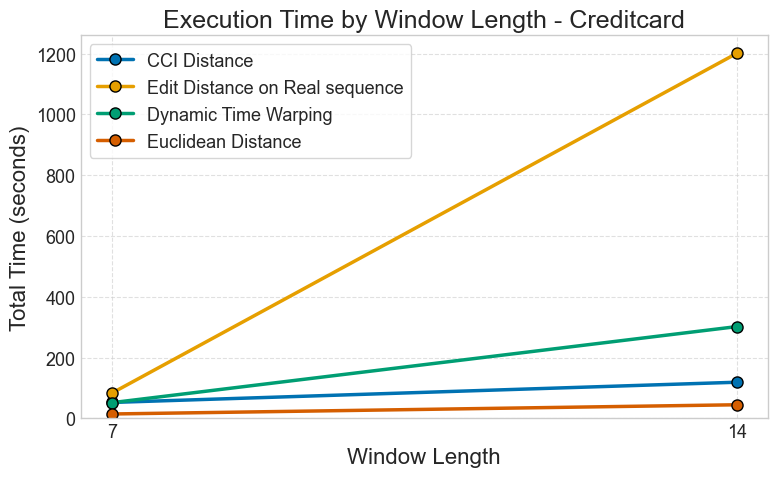

In [13]:
def extract_num(label):
    match = re.search(r'\d+', str(label))
    return int(match.group()) if match else 0

for dataset, metrics in diccionario.items():
    fig, ax = plt.subplots(figsize=(8, 5))

    for i, (metric, values) in enumerate(metrics.items()):
        x_raw = sorted(values.keys(), key=extract_num)
        x_labels = [str(extract_num(lbl)) for lbl in x_raw] 
        y = np.array([values[v] for v in x_raw])

        pretty_name = metric_name_map.get(metric.lower(), metric.title())

        ax.plot(
            x_labels, y,
            label=pretty_name,
            linewidth=2.5,
            marker="o",
            markersize=8,
            color=colors[i % len(colors)],
            markeredgecolor="black"
        )

    ax.set_title(f"Execution Time by Window Length - {dataset.title()}")
    ax.set_xlabel("Window Length")
    ax.set_ylabel("Total Time (seconds)")
    ax.legend(frameon=True, loc="best")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim(bottom=0)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#CCCCCC")

    plt.tight_layout()
    plt.show()


In [14]:
plt.savefig("processing_time_analysis.png", dpi=300)

<Figure size 640x480 with 0 Axes>